## Digital Payment Behavior Segmentation using Clustering

**1. Problem Statement**

A digital payments company operating in the UPI and wallet ecosystem wants to understand how users behave on its platform. Not all users interact with the app in the same way. Some users make many small transactions daily, some make fewer but high-value payments, some are heavily merchant-oriented, some are largely inactive, and some may show unusual or suspicious usage patterns such as high night-time activity, high failure rate, or
repeated refund requests. The business currently has rich transaction-level and behavior-level data, but it does not have a predefined target
label such as “good user”, “risky user”, or “high-value user”. Because of this, supervised learning is not the right starting point. Instead, the company wants to segment users into natural groups based on their payment behavior so that it can understand its user base more deeply and design more precise operational, engagement, and risk strategies.

The objective of this project is to apply clustering techniques to group users with similar payment patterns. The output of the project should help the company identify meaningful behavioral segments such as high-frequency micro-payment users, premium spenders, merchant-heavy users, low-engagement users, and suspicious or anomalous users. These clusters can then be used to improve customer engagement, feature design, cashback strategies, fraud monitoring, and platform growth decisions.

**2. Domain Knowledge**

• Digital payment ecosystem: UPI and wallet platforms record not only amounts and counts, but also behavioral signals such as transaction timing, session activity, failures, refunds, merchant usage, and peer transfers.

• Behavior-based segmentation: In this domain, users are better understood through usage behavior rather than only demographics. Two users of the same age or city may behave completely differently in frequency, value, or risk patterns.

• Merchant vs peer payments: Merchant-heavy users typically use the app for shopping, bill payments, food delivery, subscriptions, and in-store payments, while peer-heavy users may use it more for transfers between friends, family, or small business settlements.

• Failure and refund patterns: High failure rates can signal technical friction, poor network conditions, incorrect payment flows, user confusion, or in some cases suspicious patterns. Refund frequency can indicate merchant issues, product quality problems, or abuse behavior.

• Night-time and weekend patterns: Transaction timing matters. Moderate night usage can be normal, but extreme concentration of activity during odd hours may indicate unusual behavior, especially when combined with high failures or refund activity.

• Session behavior: App sessions, open frequency, and session duration provide context around user engagement. Highly active users usually show stronger repeat usage and shorter decision times, while confused or suspicious users may show abnormal patterns.

• Suspicious behavior: Suspicious behavior in a payment system is rarely identified using a single variable. It usually emerges through combinations such as high transaction velocity, elevated failure ratio, high peer transfer concentration, high night usage, and unstable spend patterns.

• Business impact of segmentation: User clusters can support cashback campaigns, merchant partnerships, product personalization, churn prevention, payment UX improvements, and anomaly investigation.

**3. Data Dictionary**

**Column**                        **Meaning**

user_id:- Unique identifier for each user.

city City:- associated with the user profile.

device_type:- Primary device used for transactions, such as Android or iOS.

kyc_level:- KYC completion status such as Minimum, Full, or Premium.

account_age_months:- Age of the account in months.

account_age_band:- Grouped version of account age for easier business interpretation.

active_days_per_month:- Number of days in a month on which the user is active.

transactions_per_day :- Average number of transactions made per active day.

monthly_transaction_count :- Estimated total number of transactions in a month.

avg_transaction_amount :- Average amount spent or transferred per transaction.

max_transaction_amount :- Maximum single transaction amount observed.

total_monthly_spend :- Estimated total transaction amount for the month.

merchant_txn_ratio :- Proportion of transactions made to merchants.

peer_txn_ratio :- Proportion of transactions made to peer users.

merchant_count_month :- Estimated count of merchant transactions in a month.

peer_count_month Estimated :- count of peer transactions in a month.

failed_transactions :- Number of failed payment attempts.

failed_txn_ratio :- Proportion of failed transactions out of total transactions.

refund_requests :- Number of refund requests raised by the user.

refund_ratio :- Proportion of refund requests relative to total transactions.

night_txn_ratio :- Proportion of transactions happening at night.

weekend_txn_ratio :- Proportion of transactions happening on weekends.

session_count :- Number of app sessions in the month.

app_open_frequency :- Number of times the app is opened in the month.

avg_session_duration_min :- Average time spent per app session in minutes.

avg_gap_between_txn_hours :- Average time gap between transactions in hours.

spend_volatility :- Variation in spending behavior; higher values indicate unstable or fluctuating transaction amounts.

avg_balance_before_txn:- Estimated average account balance before a transaction.

cashback_usage_ratio:- Proportion of usage influenced by cashback or incentive-driven behavior.

suspicious_activity_score :- Composite behavioral score indicating how unusual the payment pattern appears.

**4. EDA Requirements**

Exploratory data analysis in this project should not be treated as a basic plotting exercise. The purpose of EDA is to understand how user payment behavior varies across the population, what natural patterns exist, where risk signals appear, and which features are likely to contribute strongly to clustering.

**4.1 Univariate Analysis**

• Study the distribution of transaction frequency, average amount, total monthly spend, session count, failure ratio, refund ratio, and suspicious activity score.

• Check which variables are highly skewed and may require transformation or careful interpretation. 

• Identify spread, concentration, rare values, and extreme values in behavioral variables.

• Examine the composition of categorical variables such as city, device type, KYC level, and account age band.

• Interpret business meaning from distributions, for example whether the platform is dominated by frequent low-value users or low-frequency moderate-value users

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [3]:
df=pd.read_csv('digital_payment_behavior_clustering_dataset.csv');

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    5000 non-null   object 
 1   city                       5000 non-null   object 
 2   device_type                5000 non-null   object 
 3   kyc_level                  5000 non-null   object 
 4   account_age_months         5000 non-null   int64  
 5   account_age_band           5000 non-null   object 
 6   active_days_per_month      5000 non-null   int64  
 7   transactions_per_day       5000 non-null   float64
 8   monthly_transaction_count  5000 non-null   int64  
 9   avg_transaction_amount     5000 non-null   float64
 10  max_transaction_amount     5000 non-null   float64
 11  total_monthly_spend        5000 non-null   float64
 12  merchant_txn_ratio         5000 non-null   float64
 13  peer_txn_ratio             5000 non-null   float

In [5]:
df.columns

Index(['user_id', 'city', 'device_type', 'kyc_level', 'account_age_months',
       'account_age_band', 'active_days_per_month', 'transactions_per_day',
       'monthly_transaction_count', 'avg_transaction_amount',
       'max_transaction_amount', 'total_monthly_spend', 'merchant_txn_ratio',
       'peer_txn_ratio', 'merchant_count_month', 'peer_count_month',
       'failed_transactions', 'failed_txn_ratio', 'refund_requests',
       'refund_ratio', 'night_txn_ratio', 'weekend_txn_ratio', 'session_count',
       'app_open_frequency', 'avg_session_duration_min',
       'avg_gap_between_txn_hours', 'spend_volatility',
       'avg_balance_before_txn', 'cashback_usage_ratio',
       'suspicious_activity_score'],
      dtype='object')

In [6]:
df.describe()

,account_age_months,active_days_per_month,transactions_per_day,monthly_transaction_count,avg_transaction_amount,max_transaction_amount,total_monthly_spend,merchant_txn_ratio,peer_txn_ratio,merchant_count_month,...,night_txn_ratio,weekend_txn_ratio,session_count,app_open_frequency,avg_session_duration_min,avg_gap_between_txn_hours,spend_volatility,avg_balance_before_txn,cashback_usage_ratio,suspicious_activity_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,17.557000,17.132200,4.571854,86.359400,953.655104,2621.210372,69926.961856,0.618921,0.381818,44.459400,...,0.155231,0.334804,44.68380,77.741000,5.137040,38.024910,0.376452,29765.524854,0.353066,38.125814
std,9.532037,7.441411,2.923244,68.038231,1124.154102,3233.049224,102386.040608,0.167068,0.171862,36.457276,...,0.140532,0.097757,26.04843,53.941623,2.059052,68.963554,0.165912,47254.856718,0.069424,23.971917
min,1.000000,1.000000,0.050000,1.000000,20.000000,27.370000,100.000000,0.200000,0.020000,0.000000,...,0.020000,0.180000,2.00000,3.000000,0.500000,0.200000,0.050000,50.000000,0.156000,1.000000
25%,11.000000,12.000000,2.460000,32.000000,244.002500,645.757500,13757.080000,0.507000,0.270000,15.000000,...,0.078000,0.260750,26.00000,38.000000,3.740000,5.627500,0.263000,4422.320000,0.305000,22.315000
50%,17.000000,18.000000,4.220000,75.000000,560.230000,1409.420000,35892.485000,0.608000,0.390000,38.000000,...,0.120000,0.323500,44.00000,69.000000,4.970000,10.160000,0.362000,13714.065000,0.352000,30.205000
75%,24.000000,23.000000,6.130000,127.000000,992.730000,2815.885000,78350.982500,0.715000,0.492000,66.000000,...,0.164000,0.382250,62.00000,108.000000,6.320000,22.675000,0.474000,32667.917500,0.400000,44.032500
max,58.000000,31.000000,20.110000,440.000000,7057.300000,22554.740000,900000.000000,0.959000,0.850000,225.000000,...,0.778000,0.700000,142.00000,340.000000,16.540000,250.000000,1.140000,350000.000000,0.559000,100.000000


In [7]:
df.shape

(5000, 30)

In [8]:
df.isnull().sum()

user_id                      0
city                         0
device_type                  0
kyc_level                    0
account_age_months           0
account_age_band             0
active_days_per_month        0
transactions_per_day         0
monthly_transaction_count    0
avg_transaction_amount       0
max_transaction_amount       0
total_monthly_spend          0
merchant_txn_ratio           0
peer_txn_ratio               0
merchant_count_month         0
peer_count_month             0
failed_transactions          0
failed_txn_ratio             0
refund_requests              0
refund_ratio                 0
night_txn_ratio              0
weekend_txn_ratio            0
session_count                0
app_open_frequency           0
avg_session_duration_min     0
avg_gap_between_txn_hours    0
spend_volatility             0
avg_balance_before_txn       0
cashback_usage_ratio         0
suspicious_activity_score    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
key_cols = [
    'transactions_per_day',
    'avg_transaction_amount',
    'total_monthly_spend',
    'session_count',
    'failed_txn_ratio',
    'refund_ratio',
    'suspicious_activity_score'
]

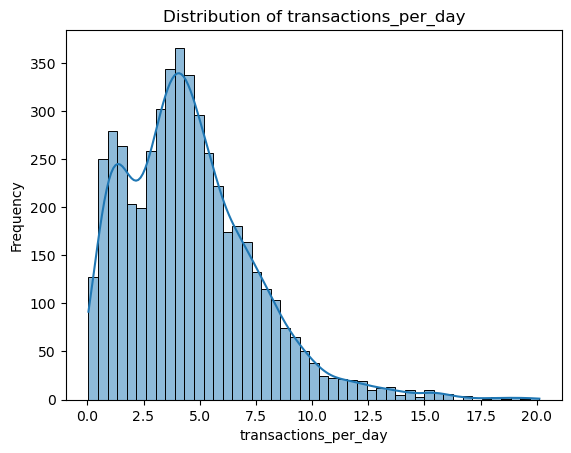

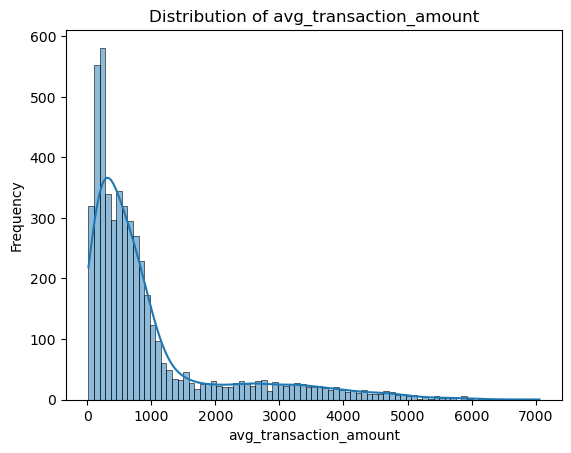

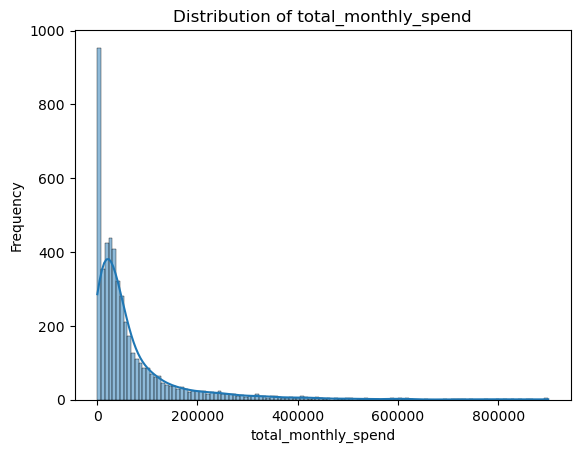

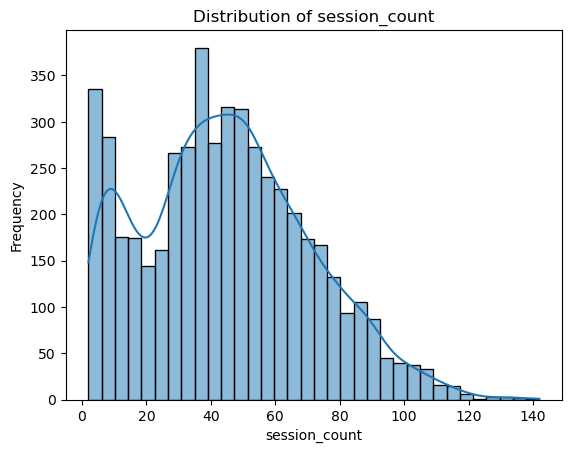

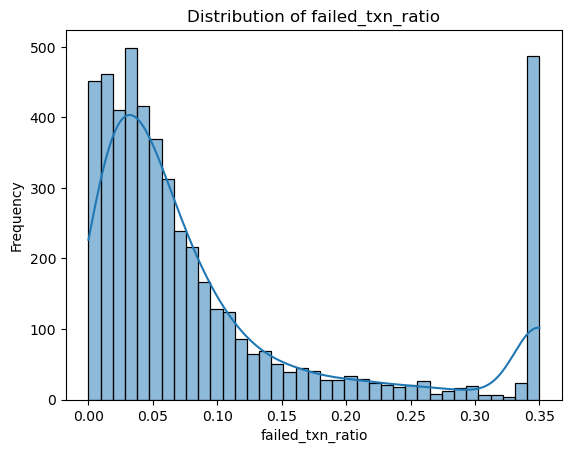

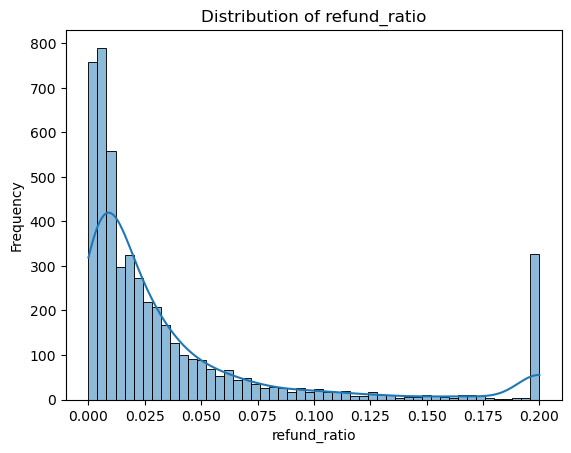

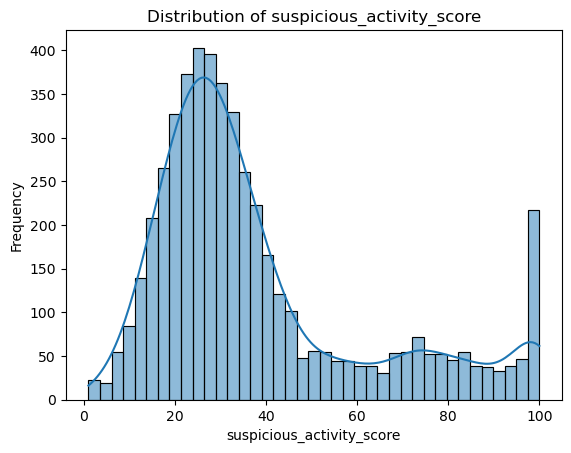

In [12]:
for col in key_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

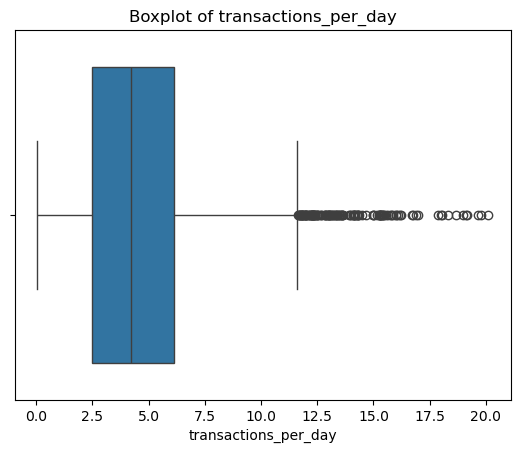

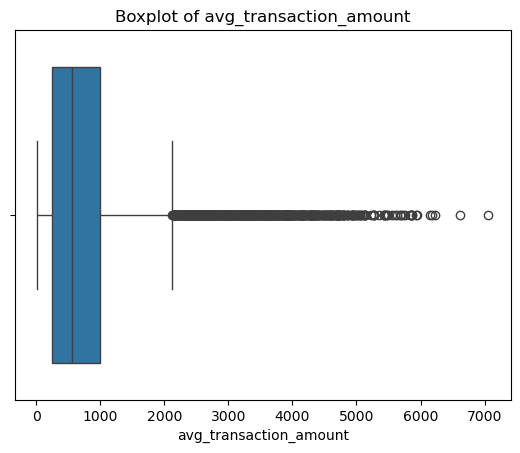

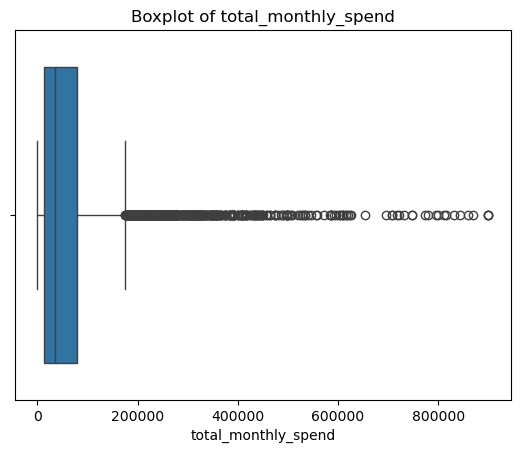

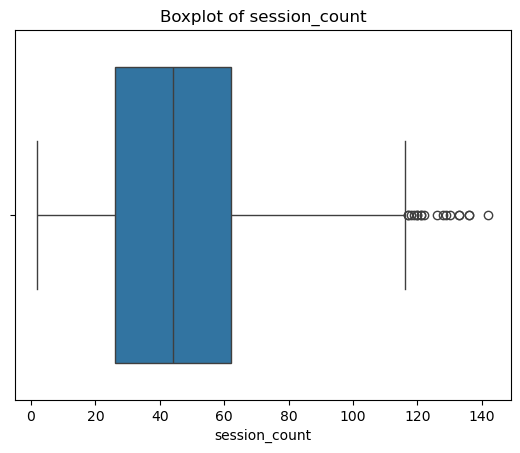

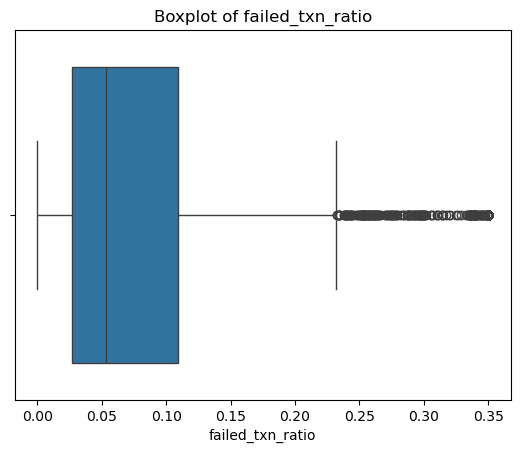

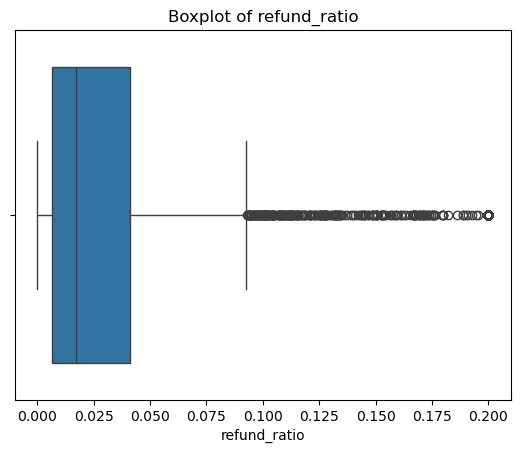

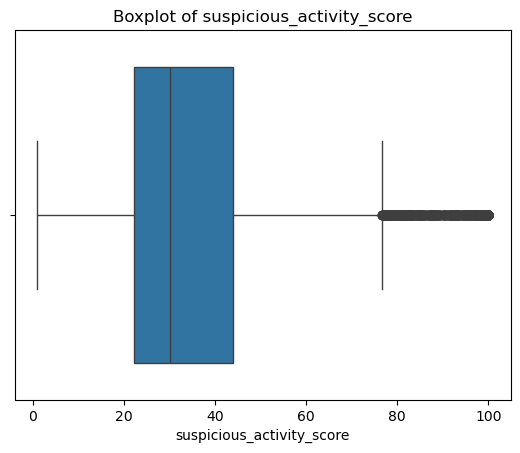

In [13]:
for col in key_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [14]:
skewness = df[key_cols].skew()
print(skewness.sort_values(ascending=False))

total_monthly_spend          3.374602
refund_ratio                 2.133922
avg_transaction_amount       2.066947
failed_txn_ratio             1.561805
suspicious_activity_score    1.252073
transactions_per_day         1.079943
session_count                0.349640
dtype: float64


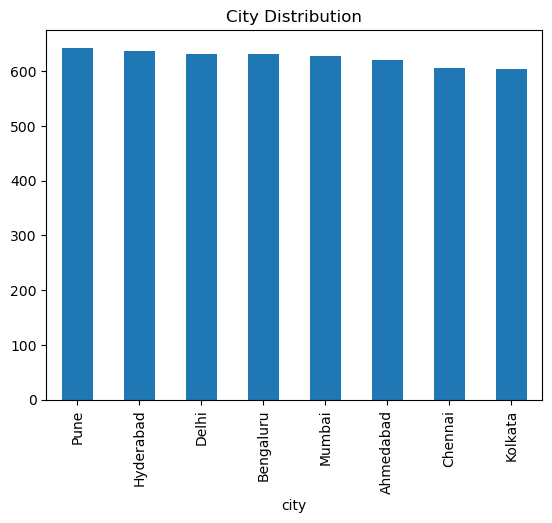

In [18]:
df['city'].value_counts().plot(kind='bar')
plt.title("City Distribution")
plt.show()

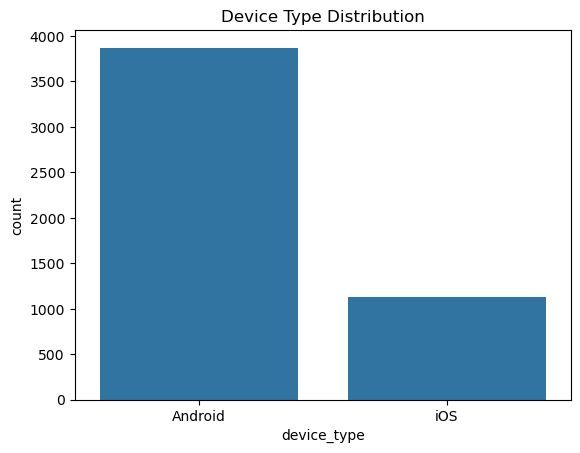

In [19]:
sns.countplot(x='device_type', data=df)
plt.title("Device Type Distribution")
plt.show()

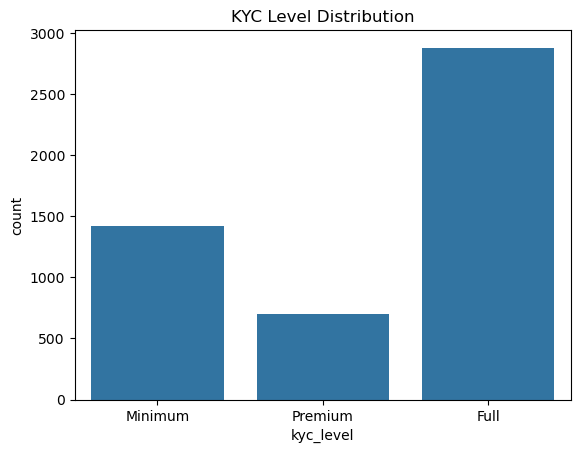

In [20]:
sns.countplot(x='kyc_level', data=df)
plt.title("KYC Level Distribution")
plt.show()

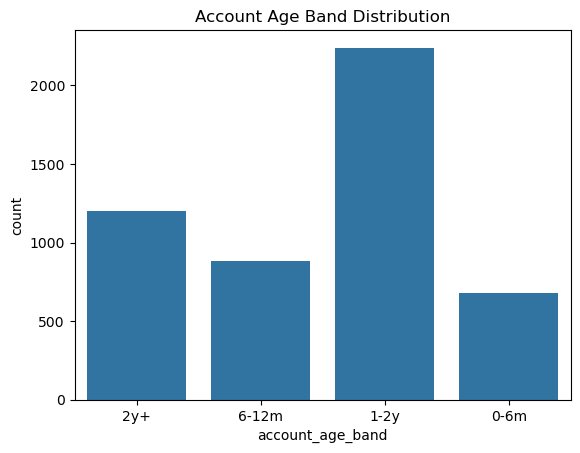

In [23]:
sns.countplot(x='account_age_band', data=df)
plt.title("Account Age Band Distribution")
plt.show()

**4.2 Bivariate Analysis**

• Examine how monthly transaction count changes with active days per month and transactions per day.

• Study the relationship between average transaction amount and total monthly spend.

• Explore how night-time activity relates to failure ratio, refund ratio, and suspicious activity score.

• Analyze merchant ratio versus cashback usage ratio to understand incentive-driven behavior.

• Examine peer ratio versus suspicious activity score to detect possible abnormal transfer patterns.

• Study session count and app open frequency together to understand engagement consistency.

• Evaluate whether account age is associated with lower or higher suspicious scores, lower failures, or stronger transaction stability

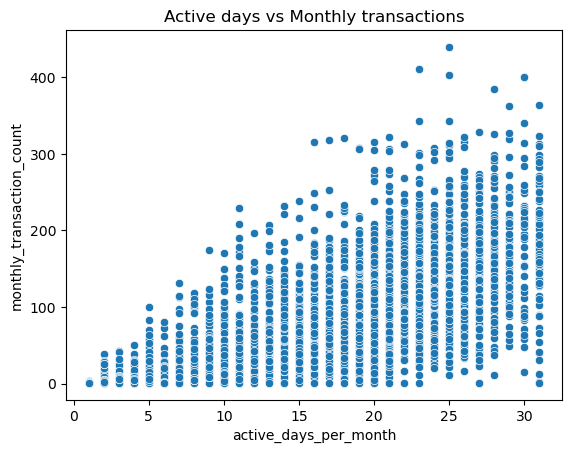

In [25]:
sns.scatterplot(x='active_days_per_month',y='monthly_transaction_count',data=df)
plt.title("Active days vs Monthly transactions")
plt.show()

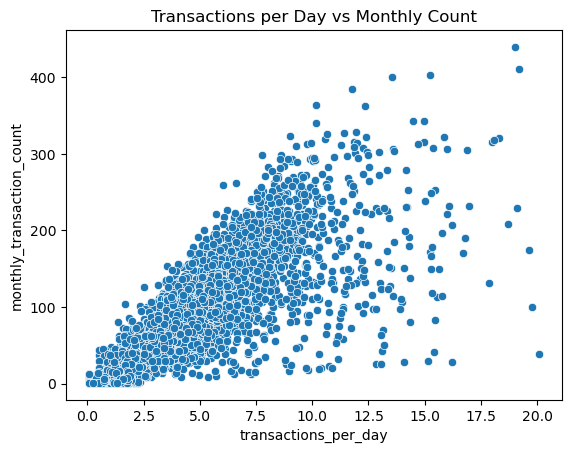

In [26]:
sns.scatterplot(x='transactions_per_day', y='monthly_transaction_count', data=df)
plt.title("Transactions per Day vs Monthly Count")
plt.show()

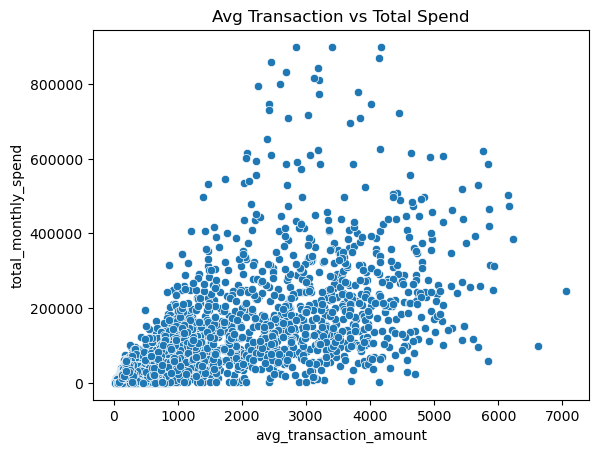

In [27]:
sns.scatterplot(x='avg_transaction_amount', y='total_monthly_spend', data=df)
plt.title("Avg Transaction vs Total Spend")
plt.show()

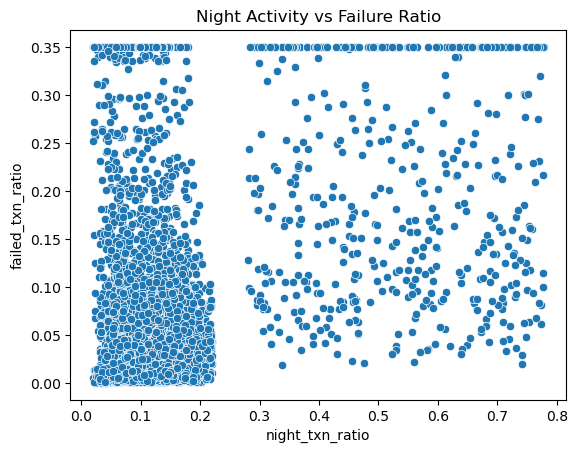

In [28]:
sns.scatterplot(x='night_txn_ratio', y='failed_txn_ratio', data=df)
plt.title("Night Activity vs Failure Ratio")
plt.show()

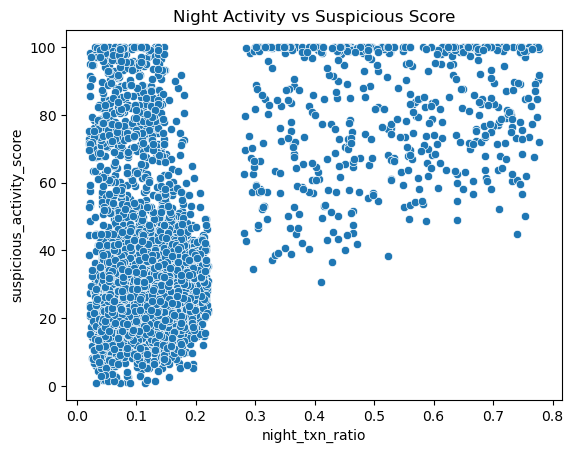

In [29]:
sns.scatterplot(x='night_txn_ratio', y='suspicious_activity_score', data=df)
plt.title("Night Activity vs Suspicious Score")
plt.show()

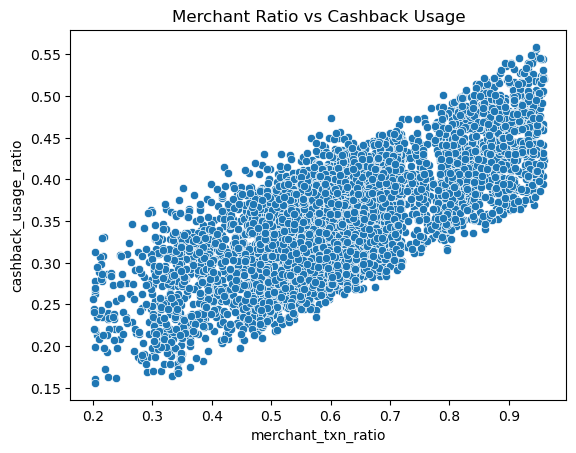

In [30]:
sns.scatterplot(x='merchant_txn_ratio', y='cashback_usage_ratio', data=df)
plt.title("Merchant Ratio vs Cashback Usage")
plt.show()

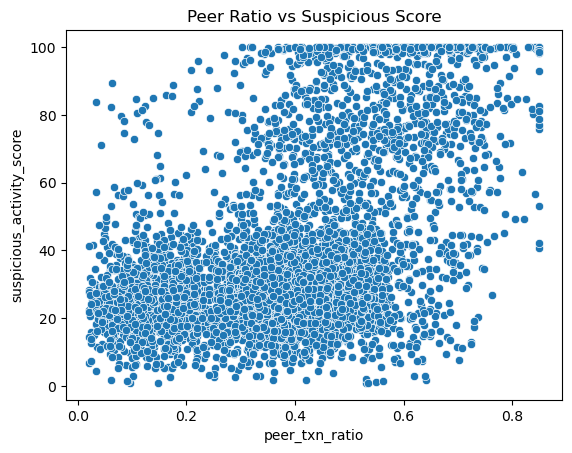

In [31]:
sns.scatterplot(x='peer_txn_ratio', y='suspicious_activity_score', data=df)
plt.title("Peer Ratio vs Suspicious Score")
plt.show()

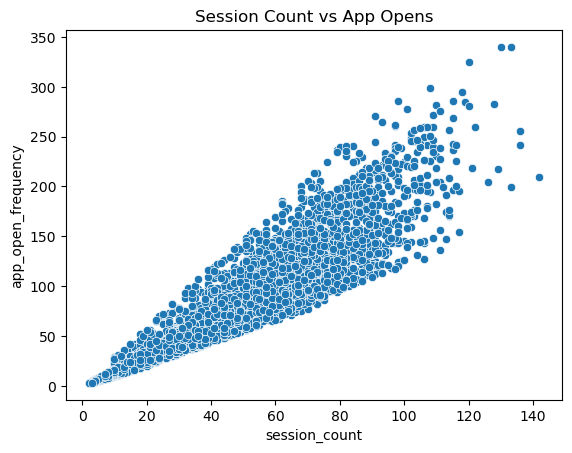

In [32]:
sns.scatterplot(x='session_count', y='app_open_frequency', data=df)
plt.title("Session Count vs App Opens")
plt.show()

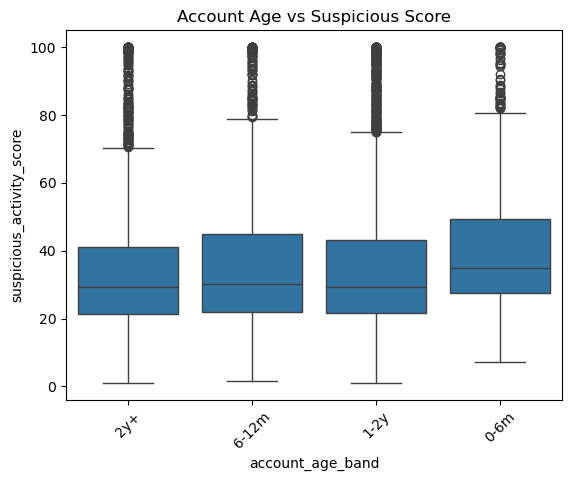

In [33]:
sns.boxplot(x='account_age_band', y='suspicious_activity_score', data=df)
plt.xticks(rotation=45)
plt.title("Account Age vs Suspicious Score")
plt.show()

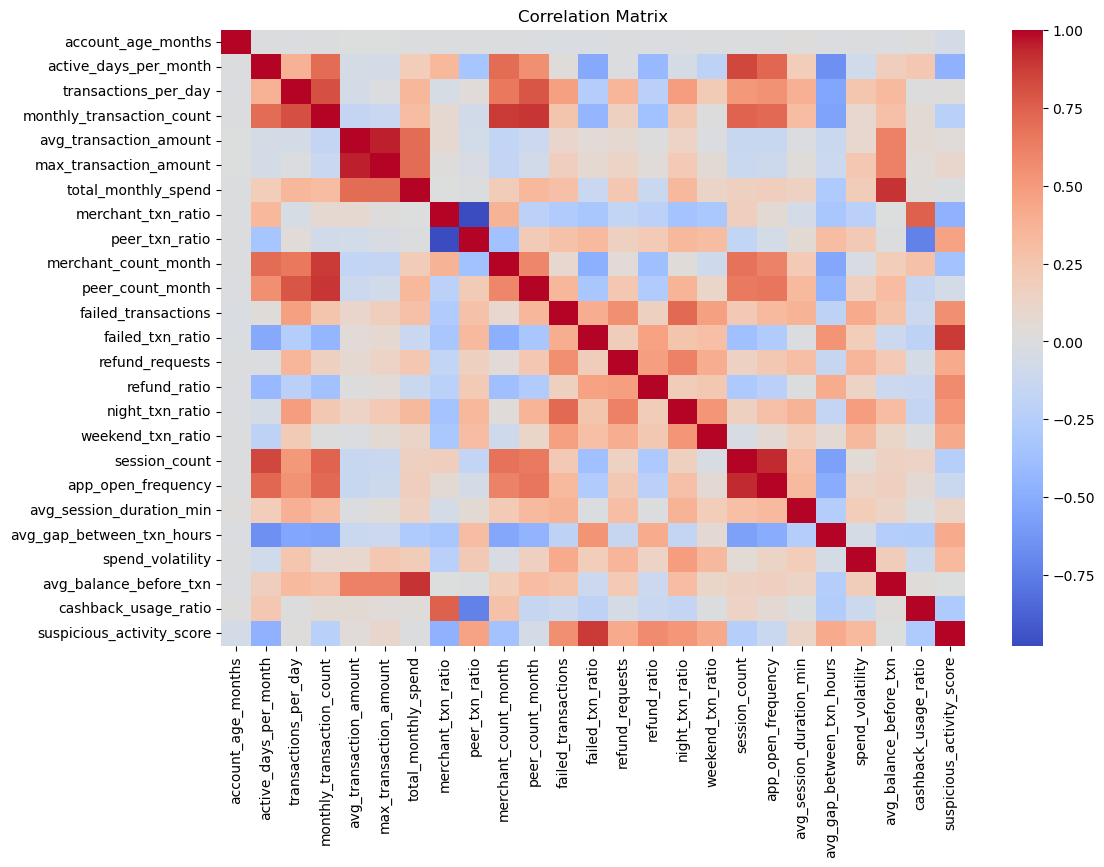

In [36]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**4.3 Multivariate Analysis**

• Perform correlation analysis on numeric features to understand direct linear relationships.

• Look for combinations of features that signal meaningful user behavior, such as high frequency plus low average amount plus high merchant usage, or high night usage plus high failures plus high refunds.

• Identify whether clear behavioral groups seem to exist before clustering by exploring multiple features together.

• Assess whether some features are strongly derived from each other and may create redundancy during modeling.

• Use business interpretation during multivariate analysis rather than relying only on statistical strength.

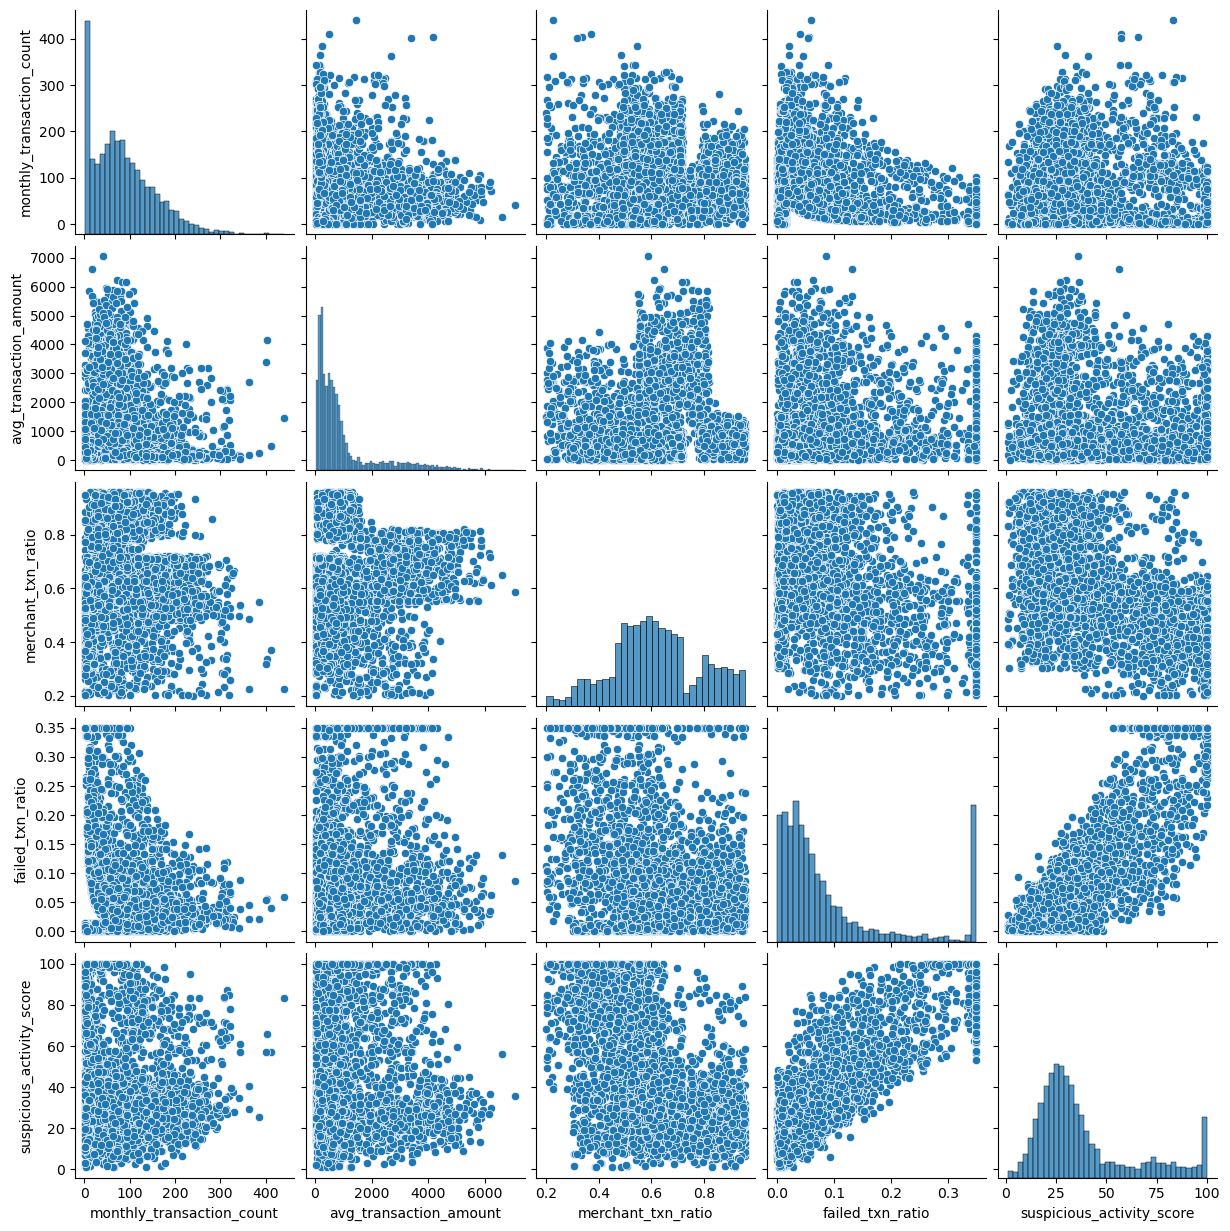

In [37]:
selected_cols = [
    'monthly_transaction_count',
    'avg_transaction_amount',
    'merchant_txn_ratio',
    'failed_txn_ratio',
    'suspicious_activity_score'
]
sns.pairplot(df[selected_cols])
plt.show()

In [38]:
df['high_freq_low_value'] = (
    (df['transactions_per_day'] > df['transactions_per_day'].median()) &
    (df['avg_transaction_amount'] < df['avg_transaction_amount'].median()))

In [39]:
df['high_freq_low_value']

0        True
1       False
2       False
3       False
4        True
        ...  
4995    False
4996     True
4997    False
4998    False
4999    False
Name: high_freq_low_value, Length: 5000, dtype: bool

In [40]:
df['premium_users'] = (
    (df['total_monthly_spend'] > df['total_monthly_spend'].quantile(0.75)) &
    (df['avg_transaction_amount'] > df['avg_transaction_amount'].quantile(0.75))
)

In [41]:
df['premium_users']

0       False
1       False
2       False
3        True
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Name: premium_users, Length: 5000, dtype: bool

In [42]:
df['suspicious_users'] = (
    (df['night_txn_ratio'] > 0.5) &
    (df['failed_txn_ratio'] > 0.3) &
    (df['refund_ratio'] > 0.2)
)

In [43]:
df['suspicious_users']

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Name: suspicious_users, Length: 5000, dtype: bool

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.select_dtypes(include=np.number))

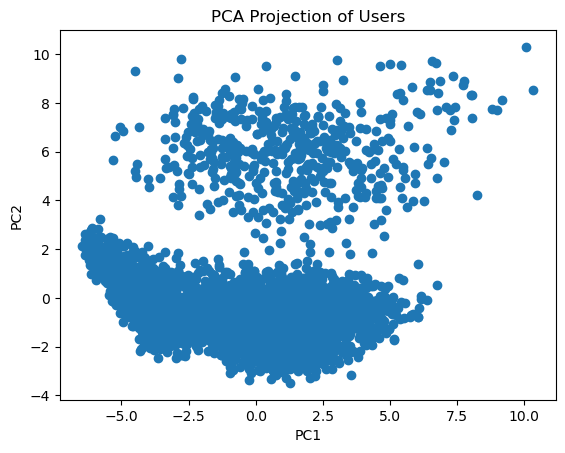

In [46]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.title("PCA Projection of Users")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [48]:
from scipy.stats import zscore

z_scores = np.abs(zscore(df.select_dtypes(include=np.number)))
outliers = (z_scores > 3).sum(axis=1)
df['outlier_flag'] = outliers > 2

In [49]:
df['outlier_flag']

0       False
1       False
2       False
3       False
4       False
        ...  
4995    False
4996    False
4997    False
4998    False
4999     True
Name: outlier_flag, Length: 5000, dtype: bool

**6. Data Preprocessing**

**6.1 Initial Checks**

• Inspect the dataset shape, column types, and sample records.

• Check for missing values, inconsistent categories, and duplicate user records.

• Validate that ratio fields fall within logical ranges such as 0 to 1.

• Check for unrealistic negative values or impossible combinations.

**6.2 Data Cleaning**

• Handle missing values if present using appropriate logic based on column type and domain meaning.

• Remove duplicate observations to ensure each user is represented once.

• Standardize categorical labels where necessary.

• Review extreme values carefully rather than dropping them blindly, because some may represent useful anomalies for DBSCAN.

**6.3 Feature Selection**

• Exclude direct identifiers such as user_id from clustering input.

• Decide whether highly derived variables should all be included together. For example, monthly_transaction_count, transactions_per_day, and active_days_per_month are related, so their contribution should be reviewed carefully.

• Keep domain relevance in mind; do not remove a feature only because it is correlated if it carries strong business meaning.

**6.4 Encoding and Scaling**

• Encode categorical variables such as city, device type, KYC level, and account age band using suitable techniques such as one-hot encoding or label encoding depending on modeling choice.

• Scale numeric variables using StandardScaler or a comparable scaling method because K-Means, DBSCAN, and Hierarchical clustering are all distance-sensitive.

• Apply the same transformed feature matrix consistently across all clustering models used for comparison.

**6.5 Outlier Handling**

• Do not remove all outliers before modeling. For K-Means and Hierarchical clustering, extreme values may distort distance calculations and should be reviewed. For DBSCAN, they are often part of the learning objective.

• A practical approach is to create one cleaned feature set for centroid-based clustering and another less aggressively filtered version for DBSCAN-based anomaly discovery.

In [51]:
df_dbscan = df.copy() 

In [52]:
df_model = df.drop(columns=['user_id'])

In [53]:
num_cols = df_model.select_dtypes(include=['int64','float64']).columns
cat_cols = df_model.select_dtypes(include=['object']).columns

In [57]:
selected_features=[
    'monthly_transaction_count',  
    'avg_transaction_amount',
    'total_monthly_spend',
    'merchant_txn_ratio',
    'peer_txn_ratio',
    'failed_txn_ratio',
    'refund_ratio',
    'night_txn_ratio',
    'cashback_usage_ratio',
    'session_count',
    'avg_gap_between_txn_hours',
    'spend_volatility',
    'suspicious_activity_score'
]

In [58]:
drop_columns=[
    'transactions_per_day',
    'active_days_per_month'
]

In [60]:
important_features = [
    'merchant_txn_ratio',
    'peer_txn_ratio',
    'failed_txn_ratio',
    'refund_ratio',
    'night_txn_ratio',
    'cashback_usage_ratio',
    'suspicious_activity_score'
]

In [61]:
final_cat_cols = [
    'city',
    'device_type',
    'kyc_level',
    'account_age_band'
]

In [82]:
final_features = selected_features + final_cat_cols
df_final = df_model[final_features].copy()

In [83]:
num_cols = df_final.select_dtypes(include=['int64','float64']).columns
cat_cols = df_final.select_dtypes(include=['object']).columns

In [84]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_cat = encoder.fit_transform(df_final[cat_cols])
encoded_cat_df = pd.DataFrame(
    encoded_cat,
    columns=encoder.get_feature_names_out(cat_cols)
)

In [85]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_num = scaler.fit_transform(df_final[num_cols])
scaled_num_df = pd.DataFrame(scaled_num, columns=num_cols)

In [86]:
X = pd.concat([scaled_num_df, encoded_cat_df], axis=1)
X.shape

(5000, 26)

In [87]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)
df['kmeans_cluster'] = kmeans.predict(X)

In [88]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X)

In [89]:
hc = AgglomerativeClustering(n_clusters=4)
df['hc_cluster'] = hc.fit_predict(X)

In [90]:
kmeans.fit(X)
dbscan.fit(X)
hc.fit(X)

AgglomerativeClustering(n_clusters=4)

In [91]:
num_df = df_final.select_dtypes(include=['int64','float64'])
z_scores = np.abs(zscore(num_df))
outlier_flag = (z_scores > 3)
df_final['outlier_count'] = outlier_flag.sum(axis=1)

In [93]:
df_kmeans = df_final[df_final['outlier_count'] < 3]
df_final.shape

(5000, 18)

In [94]:
df_kmeans.shape

(4980, 18)

In [95]:
df_dbscan = df_final.copy()

In [96]:
df_final['outlier_count'].value_counts()

outlier_count
0    4096
1     639
2     245
3      16
4       3
5       1
Name: count, dtype: int64

**7. Model Building**

**7.1 K-Means Clustering**

• Use K-Means when the goal is to create clear, interpretable user segments with relatively compact cluster structure.

• Start by selecting the transformed numeric feature matrix after encoding and scaling.

• Run the model for multiple values of K and evaluate them using the Elbow Method and Silhouette Score.

• Choose the value of K that gives a good balance between compactness, separation, and business interpretability.

• After fitting the model, attach cluster labels back to the dataset and profile each cluster using cluster-wise averages, medians, and categorical composition.

• Interpret each cluster in business language, for example micro-frequency users, premium spenders, merchant-leaning users, low-engagement users, or cashback-driven users.

• K-Means is usually the strongest baseline model for this type of behavior segmentation

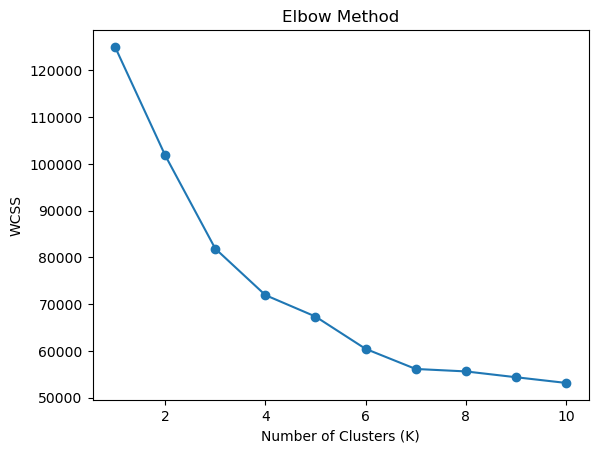

In [104]:
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [99]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(X)

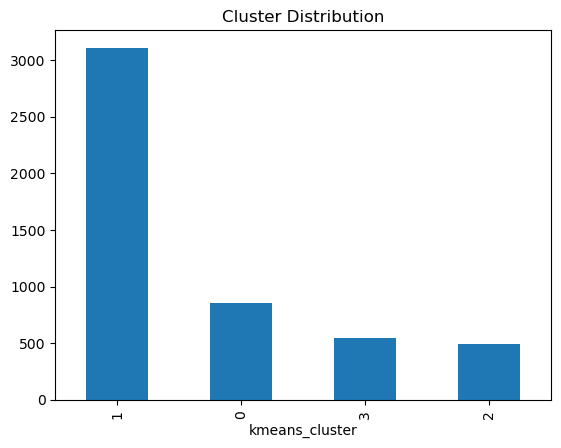

In [100]:
df['kmeans_cluster'].value_counts().plot(kind='bar')
plt.title("Cluster Distribution")
plt.show()

In [110]:
cluster_profile = df.groupby('kmeans_cluster').mean(numeric_only=True).round(2)
print(cluster_profile)

                account_age_months  active_days_per_month  \
kmeans_cluster                                              
0                            17.32                   6.36   
1                            17.55                  20.47   
2                            17.46                  14.21   
3                            18.04                  17.54   

                transactions_per_day  monthly_transaction_count  \
kmeans_cluster                                                    
0                               1.18                       6.73   
1                               5.07                     107.74   
2                               8.68                     120.67   
3                               3.33                      58.01   

                avg_transaction_amount  max_transaction_amount  \
kmeans_cluster                                                   
0                               498.79                 1343.17   
1                               

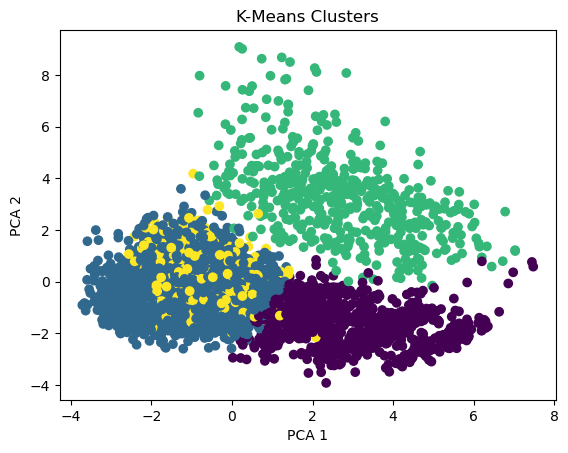

In [111]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=df['kmeans_cluster'])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clusters")
plt.show()

**2 DBSCAN**

• Use DBSCAN when the objective is to identify dense behavioral groups and isolate sparse, unusual, or potentially suspicious users.

• Because DBSCAN is highly sensitive to feature scale, ensure all relevant numeric variables are scaled before modeling.

• Tune eps and min_samples carefully. A k-distance graph can support eps selection.

• Expect DBSCAN to perform especially well in identifying outlier users such as extreme night transactors, high-failure users, or users with unusual transaction velocity.

• Unlike K-Means, DBSCAN does not require a predefined number of clusters and can mark records as noise.

• Use DBSCAN results not only for segmentation but also for anomaly screening and risk exploration

In [118]:
X_db = X

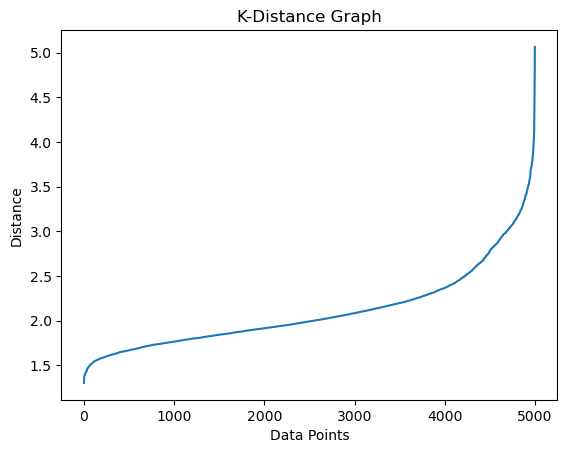

In [119]:
min_samples = 10
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_db)
distances, indices = neighbors_fit.kneighbors(X_db)
distances = np.sort(distances[:, -1])

plt.plot(distances)
plt.title("K-Distance Graph")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [120]:
dbscan = DBSCAN(eps=1.2, min_samples=10)
df['dbscan_cluster'] = dbscan.fit_predict(X_db)

In [121]:
print(df['dbscan_cluster'].value_counts())

dbscan_cluster
-1    5000
Name: count, dtype: int64


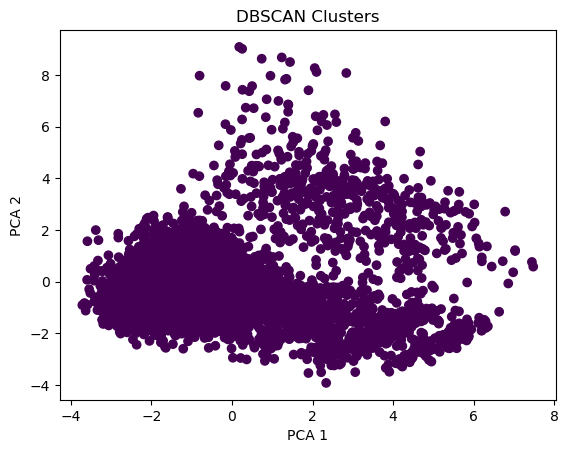

In [122]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_db)

plt.scatter(X_pca[:,0], X_pca[:,1], c=df['dbscan_cluster'])
plt.title("DBSCAN Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [123]:
suspicious_users = df[df['dbscan_cluster'] == -1]
print("Number of suspicious users:", len(suspicious_users))

Number of suspicious users: 5000


In [124]:
pd.crosstab(df['kmeans_cluster'], df['dbscan_cluster'])

dbscan_cluster,-1
kmeans_cluster,
0,852
1,3110
2,491
3,547


**7.3 Hierarchical Clustering**

• Use Hierarchical clustering when the goal is to understand how user groups form step by step and to visualize similarity structure through a dendrogram.

• Agglomerative clustering is the preferred variant for this project.

• Choose an appropriate linkage method such as Ward linkage for more compact groups or compare multiple linkages if needed.

• Use the dendrogram to decide a practical number of clusters by cutting the tree at a meaningful height.

• Hierarchical clustering is especially useful for teaching because it makes the merging process interpretable and visually intuitive.

• For large datasets, sample a manageable subset if required for dendrogram visualization.

In [125]:
X_hc = X

In [127]:
sample_size = 2000
if X_hc.shape[0] > sample_size:
    indices = np.random.choice(range(X_hc.shape[0]), sample_size, replace=False)
    X_sample = X_hc.iloc[indices]  
else:
    X_sample = X_hc

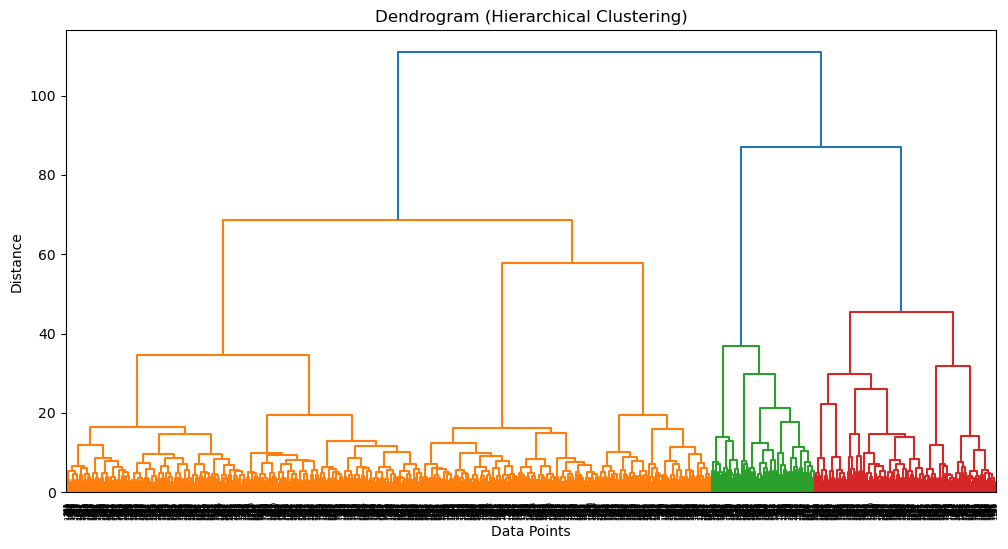

In [128]:
linked = linkage(X_sample, method='ward')
plt.figure(figsize=(12,6))
dendrogram(linked)
plt.title("Dendrogram (Hierarchical Clustering)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [129]:
hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
df['hc_cluster'] = hc.fit_predict(X_hc)

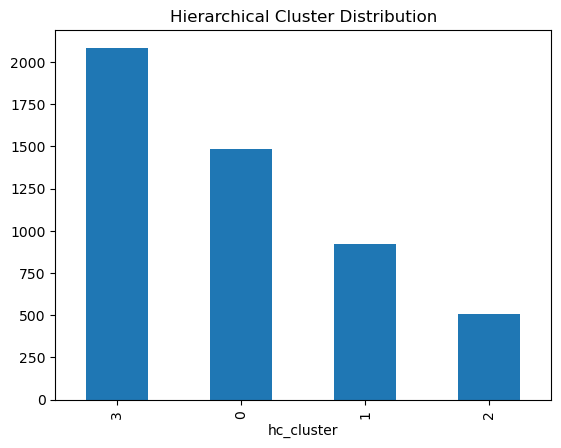

In [130]:
df['hc_cluster'].value_counts().plot(kind='bar')
plt.title("Hierarchical Cluster Distribution")
plt.show()

In [132]:
hc_profile = df.groupby('hc_cluster').mean(numeric_only=True).round(2)

In [133]:
pd.crosstab(df['kmeans_cluster'], df['hc_cluster'])

hc_cluster,0,1,2,3
kmeans_cluster,,,,
0,3,807,11,31
1,955,114,5,2036
2,0,0,491,0
3,525,3,2,17


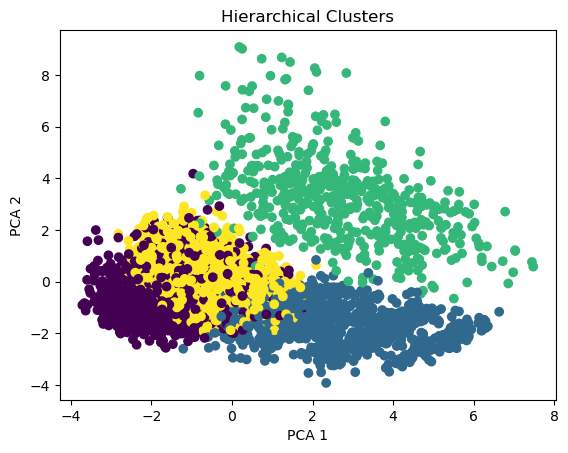

In [134]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_hc)
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['hc_cluster'])
plt.title("Hierarchical Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()